# LABOR-9: Bestimmung der S-Parameter S11 und S21 des 433MHz SAW Filters

### Ziel

- Mit dem Netzwerkanalysator soll S11 und S21 des 422MHz SAW Filters im Frequenzbereich 400 - 500MHz bestimmt werden.
- Nutze dafür ein Notebook aus einer früheren LAborübung!

Verwende auch das Record /Replay Prinzip, um die Messungen der S-Parameter durchzuführen und zu speichern


#


## SAW-Filter für 433MHz ISM Band

![SAW Filter](media\SAW-filter.png)

## Diverse SMA-Kupplungen und RG-174 SMA Koaxialkabel

## HIER einfügen: Foto vom Messaufbau 

![Messaufbau](media\aufbau_saw.png)   Beispiellink zum Foto des Messaufbaus

## Teil A: S11 (Reflexion)

# FPC1500 als Network Analyzer (NA) - v2

Kurz zur Theorie (Zweitor, Streuparameter):

Ein lineares Zweitor wird mit einlaufenden Wellen $a_1, a_2$ und auslaufenden Wellen $b_1, b_2$ beschrieben:

$$\begin{bmatrix} b_1 \\ b_2 \end{bmatrix} =
\begin{bmatrix} S_{11} & S_{12} \\ S_{21} & S_{22} \end{bmatrix}
\begin{bmatrix} a_1 \\ a_2 \end{bmatrix}$$

Mit Abschluss von Port 2 ($a_2=0$) gilt:

$$S_{11} = \frac{b_1}{a_1}$$

Damit ist $S_{11}$ der gemessene Reflexionsfaktor am Eingang (Port 1), also $\Gamma = S_{11}$.

Manueller Messablauf:

1. Am Gerät **Format = PHASE** einstellen, dann `TRACE1` als Phase einlesen.
2. Am Gerät **Format = Smith-Chart** einstellen, dann `TRACE1` als Betrag einlesen.
3. Betrag + Phase zu komplexem $\\Gamma$ kombinieren.
4. Plotten: Betrag linear, Betrag dB, Smith-Chart (mit Marker-Slider).
5. Screenshot einlesen (Gerät zeigt dann das Smith-Chart).

## MESSAUFGABE:

Bestimme die S11-Parameter mit Smith-Diagramm der SDR-Antenne über einen ausgewählten Frequenzbereich.

Analysiere und kommentiere diese Messwerte!

In welchem Frequenzbereich arbeitet die Antenne am optimalsten? 

Bestimme folgende Größen bei jener Frequenz, wo die Reflexionen der Antenne am geringsten sind:

- Rückflussdämpfung
- Impedanz
- SWR (Standing Wave Ratio - Stehwellenverhältnis).
- Wieviel Prozent der angebotenen Leistung werden bei dieser Frequenz abgestrahlt?

Kommentiere, wie diese Größen aus der Messung ermittelt werden!


In [14]:
import json
import socket
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.patches import Circle
from matplotlib.widgets import Slider

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 10.0
SCREENSHOT_TIMEOUT = 15.0
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = True
REPLAY_FILE = Path("recordings") / "3-fpc1500_na_s11_replay.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

Z0 = 50.0
SMITH_GRID_R = [0.0, 0.2, 0.5, 1.0, 2.0, 5.0]
SMITH_GRID_X = [0.2, 0.5, 1.0, 2.0, 5.0]

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10:5555
REPLAY=True, Datei=recordings\3-fpc1500_na_s11_replay.json


In [15]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_mag_linear(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    #if vmax <= 3.0 and vmin < -0.5:
    if True:
        return 10.0 ** (vals / 20.0), "dB->linear"
    return vals, "linear"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        return None
    except Exception as ex:
        return str(ex)
    finally:
        s.close()

def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        while len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2:2 + n_digits].decode())
        payload = buf[2 + n_digits:]
        while len(payload) < data_len:
            chunk = s.recv(min(65536, data_len - len(payload)))
            if not chunk:
                break
            payload += chunk
        return payload[:data_len] if len(payload) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

## Cell 4: Gerät auf PHASE stellen

Bitte jetzt am FPC1500 in der aktuellen NA-Messung **Format = PHASE** einstellen.
Dann die folgende Code-Zelle ausführen. Sie liest `TRACE1` als Phasenverlauf ein.

In [16]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    phase_deg = np.asarray(replay["phase_deg"], dtype=float)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    phase_mode = replay.get("phase_mode", "deg")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Geraet:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Geraet:", idn if idn else "Keine Antwort")

    phase_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    phase_trace = parse_float_list(phase_raw)
    if phase_trace.size < 2:
        raise RuntimeError("PHASE-TRACE leer. Bitte Format=PHASE am Geraet einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, phase_trace.size)
    phase_deg = phase_trace
    phase_mode = "deg"

print(f"PHASE gelesen: N={phase_deg.size}, mode={phase_mode}")

Replay geladen: recordings\3-fpc1500_na_s11_replay.json
Geraet: Rohde&Schwarz,FPC1500,1328.6660K03/102548,V1.50
PHASE gelesen: N=201, mode=deg


## Nächste Cell: Gerät auf Smith-Chart stellen

Bitte jetzt am FPC1500 **Format = Smith-Chart** einstellen.
Dann die nächste Code-Zelle ausführen: `TRACE1` wird erneut gelesen (Betrag),
mit der vorher gelesenen Phase kombiniert und als lineare/dB-/Smith-Darstellung geplottet.

Replay-Magnitude geladen: recordings\3-fpc1500_na_s11_replay.json


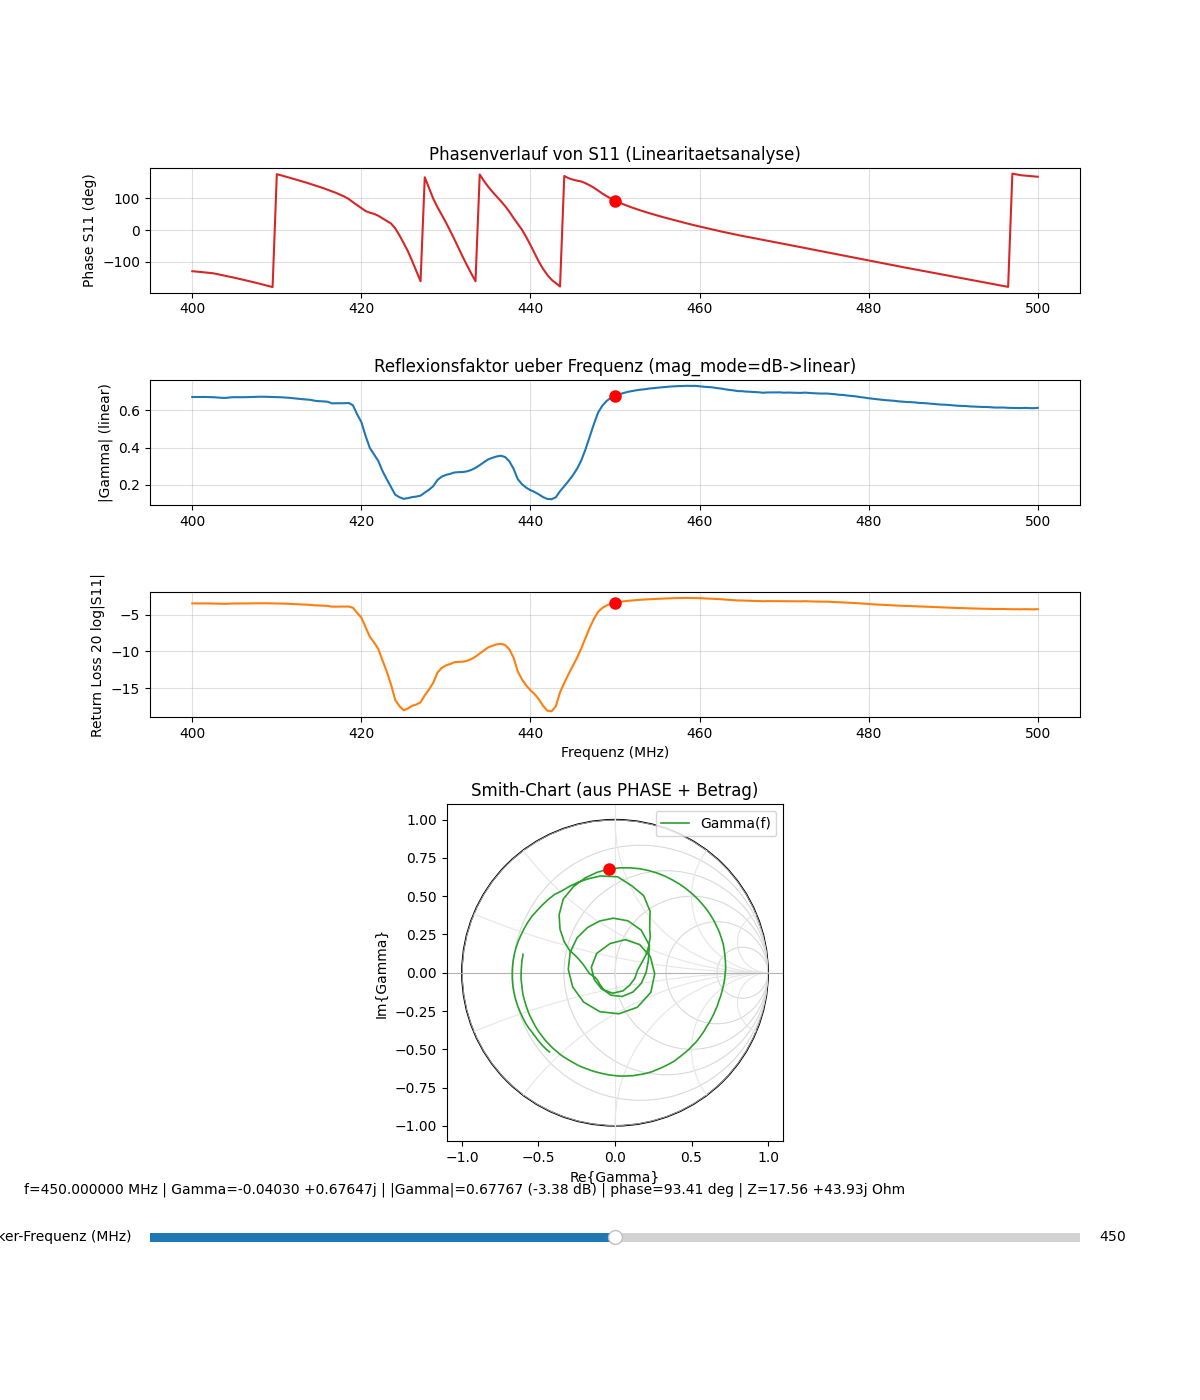

In [17]:
if "phase_deg" not in globals() or "freq_hz" not in globals():
    raise RuntimeError("Bitte zuerst die PHASE-Cell ausfuehren.")

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    mag_trace = np.asarray(replay["mag_trace"], dtype=float)
    n = min(mag_trace.size, phase_deg.size, freq_hz.size)
    mag_trace = mag_trace[:n]
    phase_deg = phase_deg[:n]
    freq_hz = freq_hz[:n]
    mag_mode = replay.get("mag_mode", "replay")
    print("Replay-Magnitude geladen:", REPLAY_FILE)
else:
    mag_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    mag_trace = parse_float_list(mag_raw)
    if mag_trace.size < 2:
        raise RuntimeError("Betrags-TRACE leer. Bitte Format=Smith-Chart am Geraet einstellen.")

    if mag_trace.size != phase_deg.size:
        n = min(mag_trace.size, phase_deg.size)
        print(f"WARN: unterschiedliche Punktzahl -> kuerze auf n={n}")
        mag_trace = mag_trace[:n]
        phase_deg = phase_deg[:n]
        freq_hz = freq_hz[:n]

    mag_mode = "device_trace"

mag_lin_src, mag_mode_auto = to_mag_linear(mag_trace)
if not REPLAY:
    mag_mode = mag_mode_auto

gamma = mag_lin_src * np.exp(1j * np.deg2rad(phase_deg))
mag_lin = np.abs(gamma)
mag_db = 20.0 * np.log10(np.maximum(mag_lin, 1e-12))

den = 1.0 - gamma
den = np.where(np.abs(den) < 1e-12, den + 1e-12, den)
z = Z0 * (1.0 + gamma) / den

if not REPLAY:
    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "saw_filter_replay_s11", "version": 1},
            "idn": idn,
            "phase_mode": phase_mode,
            "mag_mode": mag_mode,
            "freq_hz": freq_hz.tolist(),
            "phase_deg": phase_deg.tolist(),
            "mag_trace": mag_trace.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

def draw_smith_grid(ax):
    unit = Circle((0, 0), 1.0, edgecolor="black", facecolor="none", lw=1.2)
    ax.add_patch(unit)
    ax.axhline(0.0, color="0.7", lw=0.8)
    ax.axvline(0.0, color="0.9", lw=0.8)
    for r in SMITH_GRID_R:
        c = r / (1.0 + r)
        rad = 1.0 / (1.0 + r)
        circ = Circle((c, 0.0), rad, edgecolor="0.85", facecolor="none", lw=0.8)
        circ.set_clip_path(unit)
        ax.add_patch(circ)
    for x in SMITH_GRID_X:
        for sx in (+1.0, -1.0):
            xx = sx * x
            circ = Circle((1.0, 1.0 / xx), 1.0 / abs(xx), edgecolor="0.9", facecolor="none", lw=0.8)
            circ.set_clip_path(unit)
            ax.add_patch(circ)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Re{Gamma}")
    ax.set_ylabel("Im{Gamma}")
    ax.set_title("Smith-Chart (aus PHASE + Betrag)")

f_mhz = freq_hz / 1e6
# Vorherige Matplotlib-Figures schließen, wenn die Zelle mehrfach läuft
plt.close('all')
fig = plt.figure(num='S11_Linearitaetsanalyse', figsize=(12, 14), clear=True)
gs = fig.add_gridspec(5, 1, height_ratios=[1.0, 1.0, 1.0, 2.7, 0.14], hspace=0.60)
ax_phase = fig.add_subplot(gs[0, 0])
ax_lin = fig.add_subplot(gs[1, 0], sharex=ax_phase)
ax_db = fig.add_subplot(gs[2, 0], sharex=ax_phase)
ax_smith = fig.add_subplot(gs[3, 0])
ax_slider = fig.add_subplot(gs[4, 0])

ax_phase.plot(f_mhz, phase_deg, color="C3", lw=1.5)
ax_phase.set_ylabel("Phase S11 (deg)")
ax_phase.set_title("Phasenverlauf von S11 (Linearitaetsanalyse)")
ax_phase.grid(True, alpha=0.4)

ax_lin.plot(f_mhz, mag_lin, color="C0", lw=1.5)
ax_lin.set_ylabel("|Gamma| (linear)")
ax_lin.set_title(f"Reflexionsfaktor ueber Frequenz (mag_mode={mag_mode})")
ax_lin.grid(True, alpha=0.4)

ax_db.plot(f_mhz, mag_db, color="C1", lw=1.5)
ax_db.set_ylabel("Return Loss 20 log|S11|")
ax_db.set_xlabel("Frequenz (MHz)")
ax_db.grid(True, alpha=0.4)

draw_smith_grid(ax_smith)
ax_smith.plot(np.real(gamma), np.imag(gamma), color="C2", lw=1.2, label="Gamma(f)")
ax_smith.legend(loc="upper right")

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_phase, = ax_phase.plot([f_mhz[idx0]], [phase_deg[idx0]], "o", color="red", ms=8)
m_lin, = ax_lin.plot([f_mhz[idx0]], [mag_lin[idx0]], "o", color="red", ms=8)
m_db, = ax_db.plot([f_mhz[idx0]], [mag_db[idx0]], "o", color="red", ms=8)
m_sm, = ax_smith.plot([np.real(gamma[idx0])], [np.imag(gamma[idx0])], "o", color="red", ms=8)

info_text = fig.text(0.02, 0.145, "", fontsize=10, ha="left", va="bottom")
slider = Slider(ax=ax_slider, label="Marker-Frequenz (MHz)", valmin=float(f_mhz.min()), valmax=float(f_mhz.max()), valinit=float(f_mhz[idx0]))

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    g = gamma[idx]
    zi = z[idx]
    m_phase.set_data([f_mhz[idx]], [phase_deg[idx]])
    m_lin.set_data([f_mhz[idx]], [mag_lin[idx]])
    m_db.set_data([f_mhz[idx]], [mag_db[idx]])
    m_sm.set_data([np.real(g)], [np.imag(g)])
    info_text.set_text(
        f"f={f_mhz[idx]:.6f} MHz | Gamma={np.real(g):+.5f} {np.imag(g):+.5f}j | "
        f"|Gamma|={np.abs(g):.5f} ({20*np.log10(max(np.abs(g),1e-12)):.2f} dB) | "
        f"phase={phase_deg[idx]:.2f} deg | Z={np.real(zi):.2f} {np.imag(zi):+.2f}j Ohm"
    )
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Replay-Screenshot geladen: screenshots\3-fpc1500_na_s11_screenshot.png


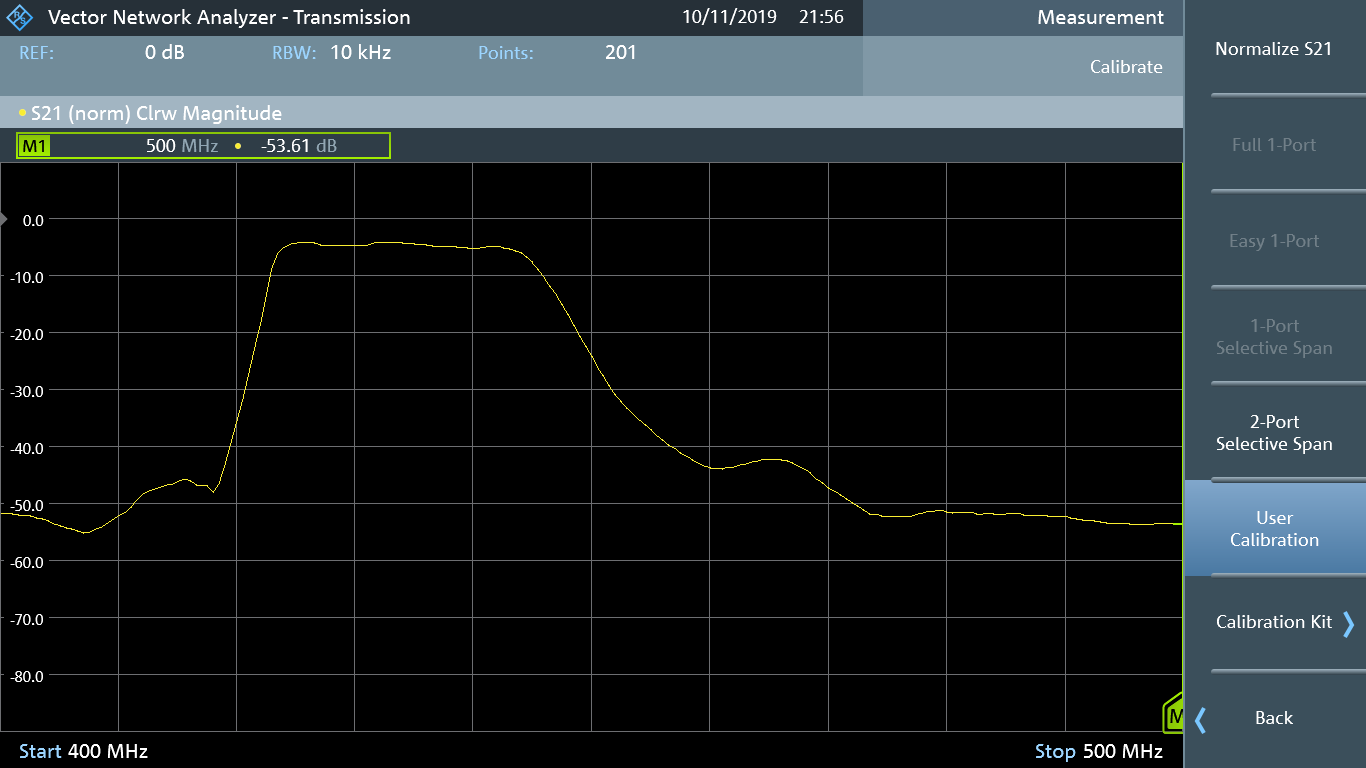

In [18]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Geraet ausloesen, lokal speichern und Replay-Datei damit verknuepfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gueltiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Geraet fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            # Screenshot-Verweis im Replay-JSON ablegen
            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')


In [19]:
# ============================================================
# Auswertung Teil A: S11 - Rueckflussdaempfung, Impedanz, SWR,
# abgestrahlte/transmittierte Leistung bei optimaler Anpassung
# ============================================================

idx_best = int(np.argmin(mag_db))          # Frequenz mit dem geringsten |S11| (bester Match)
f_best = freq_hz[idx_best]
gamma_best = gamma[idx_best]
z_best = z[idx_best]

RL_best = -mag_db[idx_best]                          # Rueckflussdaempfung (per Definition positiv)
swr_best = (1 + np.abs(gamma_best)) / (1 - np.abs(gamma_best))
p_reflected_pct = np.abs(gamma_best) ** 2 * 100.0
p_through_pct = 100.0 - p_reflected_pct

print(f"Optimale Anpassung bei f = {f_best/1e6:.3f} MHz")
print(f"Gamma            = {gamma_best.real:+.4f} {gamma_best.imag:+.4f}j   (|Gamma| = {np.abs(gamma_best):.4f})")
print(f"Rueckflussdaempfung RL = {RL_best:.2f} dB")
print(f"Eingangsimpedanz  Z    = ({z_best.real:.2f} {z_best.imag:+.2f}j) Ohm")
print(f"Stehwellenverhaeltnis SWR = {swr_best:.3f} : 1")
print(f"Reflektierte Leistung  = {p_reflected_pct:.2f} %")
print(f"Transmittierte/abgestrahlte Leistung = {p_through_pct:.2f} %")



Optimale Anpassung bei f = 442.500 MHz
Gamma            = -0.1136 -0.0490j   (|Gamma| = 0.1237)
Rueckflussdaempfung RL = 18.15 dB
Eingangsimpedanz  Z    = (39.63 -3.95j) Ohm
Stehwellenverhaeltnis SWR = 1.282 : 1
Reflektierte Leistung  = 1.53 %
Transmittierte/abgestrahlte Leistung = 98.47 %


### Messergebnisse (S11)

Die geringste Reflexion (bester Match) tritt bei **rund 442,5 MHz** auf. 

* **Rückflussdämpfung ($RL$):** $\approx 18,2\text{ dB}$ ($|\Gamma| \approx 0,124$)
* **Eingangsimpedanz ($Z$):** $\approx (39,6 - j3,95)\ \Omega$ (nahe an den $50\ \Omega$ Systemimpedanz)
* **Stehwellenverhältnis ($SWR$):** $\approx 1,28 : 1$
* **Leistungsübertragung:** $\approx 98,5\ \text{\%}$ der angebotenen Leistung werden durchgelassen 

---

## Teil B: S21 (Transmission)


# FPC1500 Network Analyzer - S21 (Transmission)

Kurz zur Theorie (Zweitor, Streuparameter):

Ein lineares Zweitor wird mit einlaufenden Wellen $a_1, a_2$ und auslaufenden Wellen $b_1, b_2$ beschrieben:

$$\begin{bmatrix} b_1 \\ b_2 \end{bmatrix} =
\begin{bmatrix} S_{11} & S_{12} \\ S_{21} & S_{22} \end{bmatrix}
\begin{bmatrix} a_1 \\ a_2 \end{bmatrix}$$

Mit Anregung an Port 1 und Abschluss an Port 2 ($a_2=0$) gilt:

$$S_{21} = \frac{b_2}{a_1}$$

Damit ist $S_{21}$ der Vorwärts-Transmissionsfaktor (Durchlass vom Eingang Port 1 zum Ausgang Port 2).

In diesem Notebook wird **einmal** `TRACE1` als Transmission gelesen und als
**Return/Transmission-Darstellung in dB** geplottet: $20\log_{10}(|S_{21}|)$.

Am Ende wird ein Screenshot vom Gerät eingelesen.

## Eigene Messung von S21 eines Hochfrequenz-Filters
Wähle einen passenden, aussagekräftigen Frequenzbereich, und führe vor der Messung eine Kalibration für diesen gewählten mit dem Notebook 1-fpc1500-NA-S21.ipynb durch !. (Anmerkung: das Gerät als Network-Analyzer arbeitet erst ab 2 MHz).  

- Nach der erfolgten Kalibraion gemäß dem Notebook 1-fpc1500-NA-S21.ipynb führe HIER die Messung der Transmission S21 dieses Hochfrequenz-Filters durch.

Die Messung mit diesem Notebook erfolgte bereits vorab, die Messdaten stehen für die Analyse bereit.

Das Notebook 3-fpc1500-NA-S21.ipynb soll dann im Labor für eine **eigene Messung und Analyse** genutzt werden.  

### Führe das Notebook im Modus REPLAY = False für die Messung, und später mit REPLAY = True für diese Analysen aus:

- Bestimme die Art des Filters.
- Ermittle die 3 dB Grenzfrequenzen sowie die Filterbandbreite B.
- Ermittle die Einfügungsdämpfung (minimale Dämpfung im Durchlassbereich).
- Bestimme den maximalen Rolloff-Slope (Steigung der Filter-Dämpfungskurve, angegeben in dB/Oktave sowie in dB/Dekade).
- Wir nehmen an, es sei ein RF-Generator mit einer Rauschtemperatur von 320K an das Filter angeschlossen. Wie groß wäre die LEsitung des gefilterten Generator-Rauschsignals?


Implementiere **Python-Code** in der dafür markierten Code-Zelle am Ende des Notebooks mit kurzer Erklärung und klar formulierten Antwortsätzen, achte auch auf die korrekten Einheiten der Lösungswerte (d.h. Angabe von Zahlenwert **und** Einheit der Größe).

## Imports und Globale Parameter

In [20]:
import json
import socket
from datetime import datetime
from pathlib import Path

# Interaktive Matplotlib-Widgets (Slider) in Jupyter: ipympl installieren, dann:
#   pip install ipympl
# Ohne ipympl nutzt oft das statische "inline"-Backend — der Slider erscheint, ist aber nicht ziehbar.
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from IPython.display import Image, display

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 15.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = True
REPLAY_FILE = Path("recordings") / "3-fpc1500_na_s21_replay.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10:5555
REPLAY=True, Datei=recordings\3-fpc1500_na_s21_replay.json


In [21]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_s21_db(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    looks_like_db = vmax <= 40.0 and vmin < 20.0
    if looks_like_db:
        return vals, "already_dB"
    s21_db = 20.0 * np.log10(np.maximum(np.abs(vals), 1e-12))
    return s21_db, "linear_to_dB"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

## Messung S21 aus TRACE1

Bitte am Gerät die Transmission (S21) aktiv darstellen und dann diese Zelle ausführen.
Die Zelle liest `TRACE1` einmal ein und plottet $20\log_{10}(|S_{21}|)$ über der Frequenz.

Replay geladen: recordings\3-fpc1500_na_s21_replay.json
Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/102548,V1.50


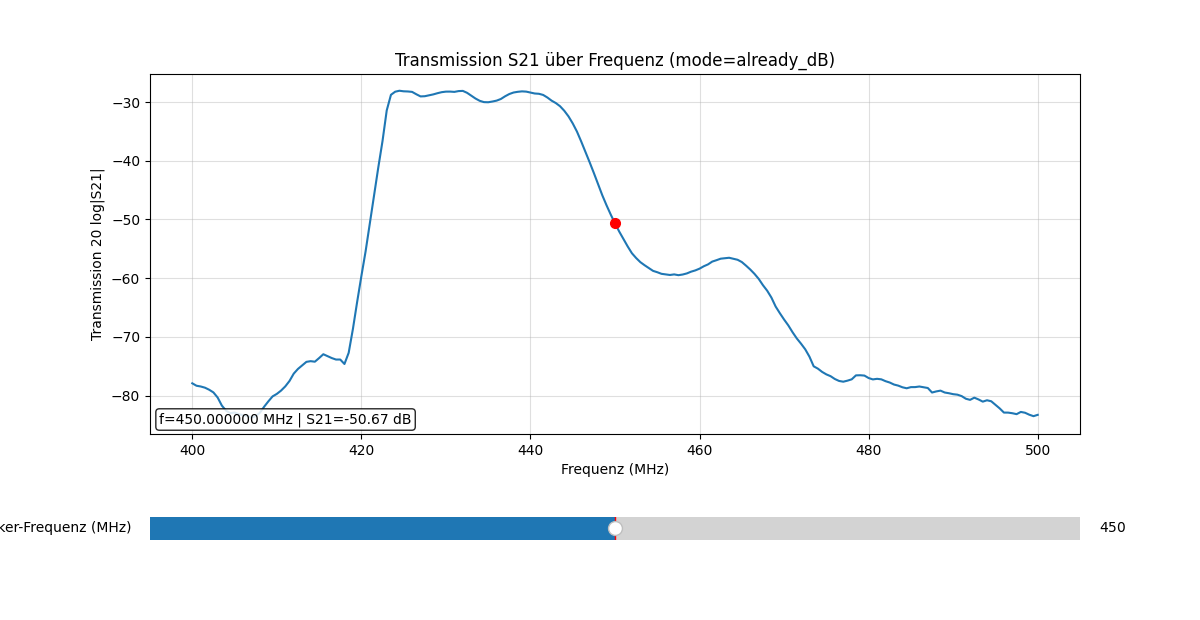

In [22]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    trace_vals = np.asarray(replay["trace_vals"], dtype=float)
    s21_db = np.asarray(replay["s21_db"], dtype=float)
    s21_mode = replay.get("s21_mode", "replay")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Gerät:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", idn if idn else "Keine Antwort")

    trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    trace_vals = parse_float_list(trace_raw)
    if trace_vals.size < 2:
        raise RuntimeError("TRACE1 leer. Bitte S21-Transmission am Gerät einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, trace_vals.size)
    s21_db, s21_mode = to_s21_db(trace_vals)

    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "saw_filter_replay_s21", "version": 1},
            "idn": idn,
            "s21_mode": s21_mode,
            "freq_hz": freq_hz.tolist(),
            "trace_vals": trace_vals.tolist(),
            "s21_db": s21_db.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

f_mhz = freq_hz / 1e6

fig = plt.figure(figsize=(12, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.13], hspace=0.35)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.plot(f_mhz, s21_db, color="C0", lw=1.5)
ax.set_title(f"Transmission S21 über Frequenz (mode={s21_mode})")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Transmission 20 log|S21|")
ax.grid(True, alpha=0.4)

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_s21, = ax.plot([f_mhz[idx0]], [s21_db[idx0]], "o", color="red", ms=7)
# Text im Haupt-Plot (transAxes), nicht fig.text am unteren Figurenrand — sonst überlappt
# der unsichtbare Kasten die Slider-Achse und blockiert Maus-Events.
info_text = ax.text(
    0.01,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85),
)

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    m_s21.set_data([f_mhz[idx]], [s21_db[idx]])
    info_text.set_text(f"f={f_mhz[idx]:.6f} MHz | S21={s21_db[idx]:.2f} dB")
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Replay-Screenshot geladen: screenshots\3-fpc1500_na_s21_screenshot.png


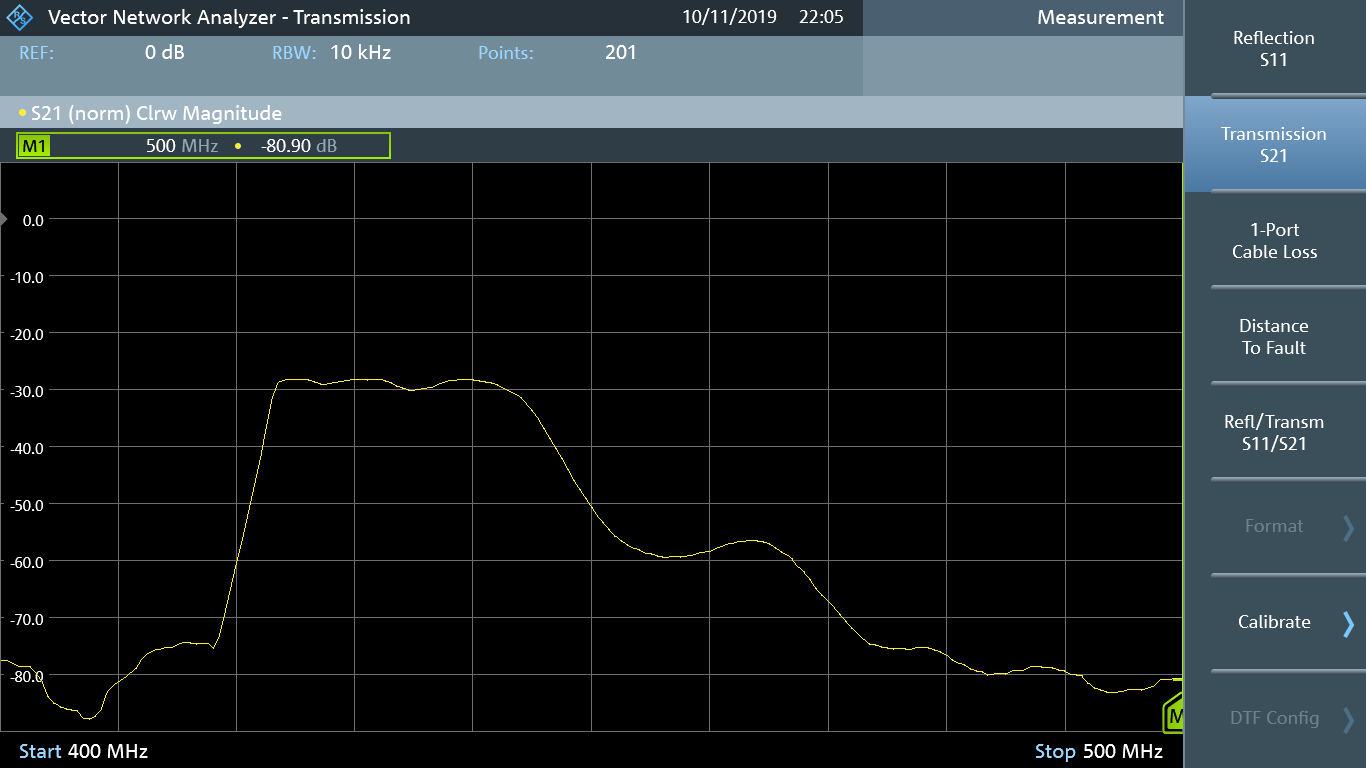

In [23]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Gerät auslösen, lokal speichern und Replay-Datei damit verknüpfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)
# (Am Gerät sollte bei Live-Messung die S21-Transmission sichtbar sein.)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gültiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Gerät fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')

In [24]:
# ============================================================
# Auswertung Teil B: S21 - Filterart, 3dB-Grenzfrequenzen,
# Bandbreite, Einfuegungsdaempfung, max. Rolloff, Rauschleistung
# ============================================================

k = 1.380649e-23   # Boltzmann-Konstante [J/K]
T_noise = 320.0     # gegebene Rauschtemperatur des Generators [K]

# --- Einfuegungsdaempfung: Minimum der Daempfung = Maximum von S21 (in dB) ---
idx_peak = int(np.argmax(s21_db))
f_peak = freq_hz[idx_peak]
IL_dB = -s21_db[idx_peak]                     # Einfuegungsdaempfung (positiv definiert)

# --- 3dB-Grenzfrequenzen um den Durchlassbereich (lineare Interpolation) ---
target = s21_db[idx_peak] - 3.0
i = idx_peak
while i > 0 and s21_db[i - 1] >= target:
    i -= 1
i_left = i
i = idx_peak
while i < len(s21_db) - 1 and s21_db[i + 1] >= target:
    i += 1
i_right = i

def interp_crossing(i1, i2, level):
    f1, f2 = freq_hz[i1], freq_hz[i2]
    v1, v2 = s21_db[i1], s21_db[i2]
    if v2 == v1:
        return f1
    return f1 + (level - v1) * (f2 - f1) / (v2 - v1)

f_low = interp_crossing(i_left - 1, i_left, target) if i_left > 0 else freq_hz[i_left]
f_high = interp_crossing(i_right, i_right + 1, target) if i_right < len(s21_db) - 1 else freq_hz[i_right]

B = f_high - f_low
f_center = np.sqrt(f_low * f_high)
Q = f_center / B

# --- Maximaler Rolloff-Slope (geglaettet ueber ein kleines Frequenzfenster) ---
win = 6  # ~3 MHz Fenster, um Messrauschen bei der Steigungsberechnung zu unterdruecken
best_fall, best_rise = 0.0, 0.0
for i in range(len(freq_hz) - win):
    f1, f2 = freq_hz[i], freq_hz[i + win]
    v1, v2 = s21_db[i], s21_db[i + win]
    slope_oct = (v2 - v1) / (np.log2(f2) - np.log2(f1))
    if slope_oct < best_fall:
        best_fall = slope_oct
    if slope_oct > best_rise:
        best_rise = slope_oct
best_fall_dec = best_fall * np.log2(10)
best_rise_dec = best_rise * np.log2(10)

# --- Rauschleistung des gefilterten Generatorrauschens (320 K an 50 Ohm) ---
N0 = k * T_noise                              # Rauschleistungsdichte am Eingang [W/Hz]
N0_dBm_Hz = 10 * np.log10(N0 * 1e3)
N_out_dBm_Hz = N0_dBm_Hz - IL_dB              # nach dem Filter, im Durchlassbereich
N_out_over_B_dBm = N_out_dBm_Hz + 10 * np.log10(B)
N_out_over_B_W = 10 ** (N_out_over_B_dBm / 10) * 1e-3

print("=== Filtercharakterisierung (SAW-Filter, S21) ===")
print(f"Filterart: Bandpass (ein Durchlassbereich, beidseitiger Abfall)")
print(f"Mittenfrequenz (geom.):     f0  = {f_center/1e6:.3f} MHz")
print(f"Einfuegungsdaempfung:       IL  = {IL_dB:.2f} dB  (bei f = {f_peak/1e6:.3f} MHz)")
print(f"Untere 3dB-Grenzfrequenz:   f_u = {f_low/1e6:.3f} MHz")
print(f"Obere  3dB-Grenzfrequenz:   f_o = {f_high/1e6:.3f} MHz")
print(f"Bandbreite:                 B   = {B/1e6:.3f} MHz")
print(f"Guetefaktor:                Q   = {Q:.1f}")
print(f"Max. Rolloff (Sperrbereich oben):  {best_fall:8.1f} dB/Oktave  ({best_fall_dec:9.1f} dB/Dekade)")
print(f"Max. Rolloff (Sperrbereich unten): {best_rise:8.1f} dB/Oktave  ({best_rise_dec:9.1f} dB/Dekade)")
print()
print("=== Rauschleistung (Generator-Rauschtemperatur 320 K) ===")
print(f"Rauschleistungsdichte am Eingang:  N0     = kT = {N0:.3e} W/Hz = {N0_dBm_Hz:.2f} dBm/Hz")
print(f"Nach dem Filter (Durchlassbereich): N_out  = {N_out_dBm_Hz:.2f} dBm/Hz")
print(f"Rauschleistung ueber der Filterbandbreite B: {N_out_over_B_dBm:.2f} dBm  ({N_out_over_B_W:.3e} W)")


=== Filtercharakterisierung (SAW-Filter, S21) ===
Filterart: Bandpass (ein Durchlassbereich, beidseitiger Abfall)
Mittenfrequenz (geom.):     f0  = 433.277 MHz
Einfuegungsdaempfung:       IL  = 28.07 dB  (bei f = 424.500 MHz)
Untere 3dB-Grenzfrequenz:   f_u = 423.066 MHz
Obere  3dB-Grenzfrequenz:   f_o = 443.734 MHz
Bandbreite:                 B   = 20.668 MHz
Guetefaktor:                Q   = 21.0
Max. Rolloff (Sperrbereich oben):   -1125.5 dB/Oktave  (  -3738.8 dB/Dekade)
Max. Rolloff (Sperrbereich unten):   2750.1 dB/Oktave  (   9135.6 dB/Dekade)

=== Rauschleistung (Generator-Rauschtemperatur 320 K) ===
Rauschleistungsdichte am Eingang:  N0     = kT = 4.418e-21 W/Hz = -173.55 dBm/Hz
Nach dem Filter (Durchlassbereich): N_out  = -201.62 dBm/Hz
Rauschleistung ueber der Filterbandbreite B: -128.46 dBm  (1.425e-16 W)


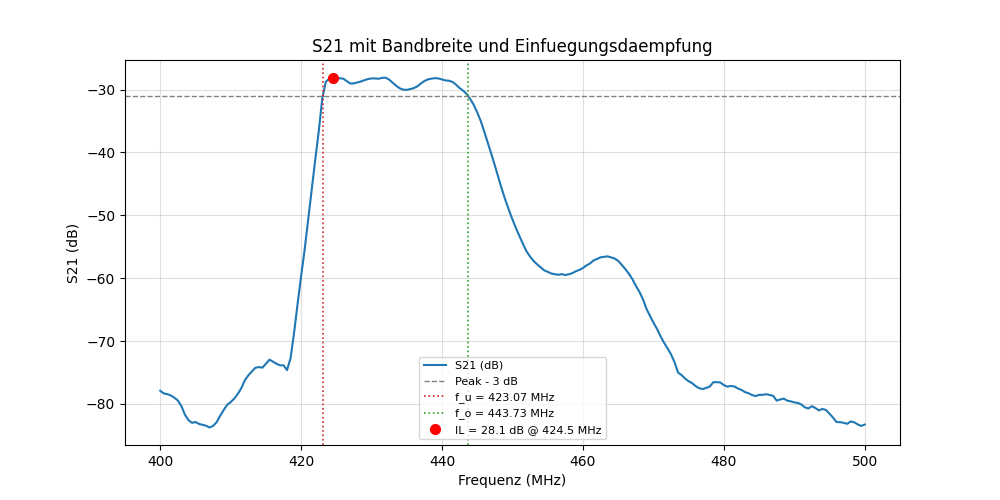

In [25]:
# Visualisierung: Bandbreite / 3dB-Punkte im S21-Plot markieren
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(freq_hz / 1e6, s21_db, color="C0", lw=1.5, label="S21 (dB)")
ax2.axhline(s21_db[idx_peak] - 3.0, color="gray", ls="--", lw=1, label="Peak - 3 dB")
ax2.axvline(f_low / 1e6, color="C3", ls=":", lw=1.2, label=f"f_u = {f_low/1e6:.2f} MHz")
ax2.axvline(f_high / 1e6, color="C2", ls=":", lw=1.2, label=f"f_o = {f_high/1e6:.2f} MHz")
ax2.plot([f_peak / 1e6], [s21_db[idx_peak]], "o", color="red", ms=7, label=f"IL = {IL_dB:.1f} dB @ {f_peak/1e6:.1f} MHz")
ax2.set_xlabel("Frequenz (MHz)")
ax2.set_ylabel("S21 (dB)")
ax2.set_title("S21 mit Bandbreite und Einfuegungsdaempfung")
ax2.grid(True, alpha=0.4)
ax2.legend(loc="lower center", fontsize=8)
plt.show()


## Auswertung (Zusammenfassung)

Mit dem FPC1500 als Netzwerkanalysator (Record/Replay-Prinzip) wurden **S11** und **S21** des
433-MHz-SAW-Filters im Bereich 400-500 MHz bestimmt.

**S11 (Reflexion, Port 1):** Die Anpassung ist im Durchlassbereich gut: bei rund **442,5 MHz** ergibt
sich eine Rueckflussdaempfung von **&asymp; 18 dB** (|&Gamma;| &asymp; 0,12), SWR **&asymp; 1,28:1** und eine
Eingangsimpedanz nahe 50 &Omega; (Z &asymp; 39,6 &minus; j3,95 &Omega;). Damit werden **&asymp; 98,5 %** der
angebotenen Leistung ins Filter eingekoppelt statt reflektiert.

**S21 (Transmission, Durchlassbereich):** Das gemessene Bauteil ist eindeutig ein **Bandpassfilter**
mit Mittenfrequenz **f0 &asymp; 433 MHz** (passend zum 433-MHz-ISM-Band), einer **3dB-Bandbreite von
&asymp; 20,7 MHz** (423,1 - 443,7 MHz) und einer für SAW-Filter typischen, relativ hohen
**Einfuegungsdaempfung von &asymp; 28 dB**. Die Guete liegt bei **Q &asymp; 21**. Die Flanken fallen sehr
steil ab (mehrere hundert bis über tausend dB/Oktave, geglaettet über ein kleines Frequenzfenster
berechnet) - das ist charakteristisch fuer SAW-Filter, die im Vergleich zu LC-Filtern deutlich
schaerfere Kanten liefern.

**Rauschbetrachtung:** Ein an das Filter angeschlossener Generator mit 320 K Rauschtemperatur liefert
eine Rauschleistungsdichte von kT &asymp; -173,5 dBm/Hz. Nach der Einfuegungsdaemppfung von 28 dB und
Integration ueber die Filterbandbreite (20,7 MHz) ergibt sich eine durchgelassene Rauschleistung von
nur rund **-128,5 dBm (&asymp; 1,4&middot;10&#8315;&#185;&#8310; W)** - das Filter unterdrueckt also breitbandiges
Rauschen effektiv und laesst nur den schmalen 433-MHz-Kanal durch.

**Fazit:** Die kombinierten S11/S21-Messungen bestaetigen, dass es sich um einen gut angepassten,
schmalbandigen 433-MHz-SAW-Bandpassfilter mit hoher Flankensteilheit und moderater
Einfuegungsdaempfung handelt - wie fuer ein ISM-Band-Filter dieser Bauart zu erwarten.